# Assignment 3
### Due 9/21. Do four of five.

In [31]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [32]:
nhanes = pd.read_csv('/Users/bellalu/DS 5030/DS5030UnderstandingUncertainty/data/nhanes_data_17_18.csv')
nhanes

/var/folders/s2/wtdgdzmj6t9f6_q7_f0t4ryh0000gn/T/ipykernel_4838/561972361.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes = pd.read_csv('/Users/bellalu/DS 5030/DS5030UnderstandingUncertainty/data/nhanes_data_17_18.csv')


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,102952.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,0.0,Never
8362,102953.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,218.0,0.0,Never
8363,102954.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66.0,150.0,0.0,Never
8364,102955.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
nhanes_meta = pd.read_csv('/Users/bellalu/DS 5030/DS5030UnderstandingUncertainty/data/nhanes_meta_17_18.csv')
nhanes_meta

,VariableNameLong,Variable,Type,Format,Informat,Label,Source,VariableName,SASLabel,EnglishText,Target,VariableNameLong_variable_df,Source_variable_df,EnglishInstructions,HardEdits,Recoded,CustomRecoding,nNonNA
0,GeneralHealthCondition,HSD010,Numeric,NaN,NaN,General health condition,HSQ,HSD010,General health condition,Next I have some general questions about {your...,Both males and females 12 YEARS -\n\n\t\t\t15...,GeneralHealthCondition,HSQ,NaN,NaN,True,NaN,5964.0
1,EverBreastfedOrFedBreastmilk,DBQ010,Numeric,NaN,NaN,Ever breastfed or fed breastmilk,DBQ,DBQ010,Ever breastfed or fed breastmilk,Now I'm going to ask you some general question...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,EverBreastfedOrFedBreastmilk,DBQ,NaN,NaN,True,YesNo,1069.0
2,AgeStoppedBreastfeedingdays,DBD030,Numeric,NaN,NaN,Age stopped breastfeeding(days),DBQ,DBD030,Age stopped breastfeeding(days),How old was {SP} when {he/she} completely stop...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,AgeStoppedBreastfeedingdays,DBQ,NaN,NaN,False,NaN,862.0
3,AgeFirstFedFormuladays,DBD041,Numeric,NaN,NaN,Age first fed formula(days),DBQ,DBD041,Age first fed formula(days),How old was {SP} when {he/she} was first fed f...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,AgeFirstFedFormuladays,DBQ,NaN,NaN,False,NaN,1077.0
4,AgeStoppedReceivingFormuladays,DBD050,Numeric,NaN,NaN,Age stopped receiving formula(days),DBQ,DBD050,Age stopped receiving formula(days),How old was {SP} when {he/she} completely stop...,Both males and females 0 YEARS -\n\n\t\t\t6 Y...,AgeStoppedReceivingFormuladays,DBQ,NaN,NaN,False,NaN,891.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,UnitOfMeasureDayweekmonthyear_2_SMQ,SMQ852U,Numeric,NaN,NaN,Unit of measure (day/week/month/year),SMQ,SMQ852U,Unit of measure (day/week/month/year),"The last time {you/SP} tried to quit, how long...",Both males and females 18 YEARS -\n\n\t\t\t15...,UnitOfMeasureDayweekmonthyear,SMQ,ENTER UNIT,NaN,True,NaN,496.0
193,CurrentSelfreportedHeightInches,WHD010,Numeric,NaN,NaN,Current self-reported height (inches),WHQ,WHD010,Current self-reported height (inches),These next questions ask about {your/SP's} hei...,Both males and females 16 YEARS -\n\n\t\t\t15...,CurrentSelfreportedHeightInches,WHQ,ENTER HEIGHT IN FEET AND INCHES OR METERS AND ...,NaN,False,NaN,5776.0
194,CurrentSelfreportedWeightPounds,WHD020,Numeric,NaN,NaN,Current self-reported weight (pounds),WHQ,WHD020,Current self-reported weight (pounds),How much {do you/does SP} weigh without clothe...,Both males and females 16 YEARS -\n\n\t\t\t15...,CurrentSelfreportedWeightPounds,WHQ,"RECORD CURRENT WEIGHT. IF PREGNANT, ASK FOR WE...",NaN,False,NaN,5828.0
195,TriedToLoseWeightInPastYear,WHQ070,Numeric,NaN,NaN,Tried to lose weight in past year,WHQ,WHQ070,Tried to lose weight in past year,"During the past 12 months, {have you/has SP} t...",Both males and females 16 YEARS -\n\n\t\t\t15...,TriedToLoseWeightInPastYear,WHQ,NaN,NaN,True,YesNo,5087.0


The first categorical variable I will choose is HowOftenDoYouSnore and the second categorical variable is GeneralHealthCondition. 

In [34]:
nhanes['HowOftenDoYouSnore'].isna().sum()

np.int64(2969)

In [35]:
nhanes['GeneralHealthCondition'].isna().sum()


np.int64(2402)

In [36]:
nhanes['HowOftenDoYouSnore'] = nhanes['HowOftenDoYouSnore'].dropna()
nhanes['GeneralHealthCondition'] = nhanes['GeneralHealthCondition'].dropna()

In [37]:
ctable = pd.crosstab(nhanes['HowOftenDoYouSnore'], nhanes['GeneralHealthCondition'])
ctable

GeneralHealthCondition,Excellent,Fair or,Good,Poor?,Very good
HowOftenDoYouSnore,,,,,
Frequently - 5 or more nights a week,83,397,616,60,263
Never,194,222,585,30,419
Occasionally - 3-4 nights a week,73,187,406,27,269
Rarely - 1-2 nights a week,122,215,498,27,335


Most people have fair health conditions. Most people also never snore. The most common scenario is that people have good health conditions and frequently snore. The second highest scenario is that people have good health conditions and never snore. In general there is a good distribution across both variables, but it appears that snoring more frequently is associated with poorer health conditions because there is a higher rate of frequent snoring in the "poor" and "fair" health conditions. On the flip side, there is a higher rate of observations in the "never" and "rarely" rows for the "Excellent" and "Very good" health conditions, indicating that there might be an association between snoring less frequently and better health conditions. However, the counts in the "occasional" row are generally lower, so there may not be an association of occassional snoring with either a better or worse health conditions.

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [38]:
nhanes.head()

,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


My categorical variable is DifficultyManagingMoney and my numeric variable is WaistCircumferenceCm. 

In [39]:
nhanes['DifficultyManagingMoney'].isna().sum()

np.int64(5602)

In [40]:
nhanes['WaistCircumferenceCm'].isna().sum()

np.int64(765)

In [41]:
nhanes['DifficultyManagingMoney'] = nhanes['DifficultyManagingMoney'].dropna()
nhanes['WaistCircumferenceCm'] = nhanes['WaistCircumferenceCm'].dropna()

In [42]:
table1 = nhanes.groupby('DifficultyManagingMoney')['WaistCircumferenceCm'].describe()
table2 = nhanes.groupby('DifficultyManagingMoney')['WaistCircumferenceCm'].agg(['min', 'max', 'median', 'mean', 'std'])

print(table1)
print('\n')
print(table2)

                          count        mean        std   min     25%    50%  \
DifficultyManagingMoney                                                       
Do not do this activity    87.0  101.356322  14.236333  71.2  91.500  102.1   
Much difficulty            65.0  103.310769  17.068896  75.7  90.300  101.3   
No difficulty            2075.0  103.602458  16.112199  62.3  92.800  102.2   
Some difficulty           297.0  105.128620  17.652877  63.7  93.900  103.5   
Unable to do               26.0  100.588462  18.287686  71.6  92.125   97.2   

                             75%    max  
DifficultyManagingMoney                  
Do not do this activity  112.000  143.6  
Much difficulty          115.000  155.1  
No difficulty            113.800  169.5  
Some difficulty          116.000  153.2  
Unable to do             108.225  152.0  


                          min    max  median        mean        std
DifficultyManagingMoney                                            
Do not do this

In [43]:
nhanes['DifficultyManagingMoney'].unique()

array([nan, 'No difficulty', 'Some difficulty', 'Do not do this activity',
       'Much difficulty', 'Unable to do'], dtype=object)

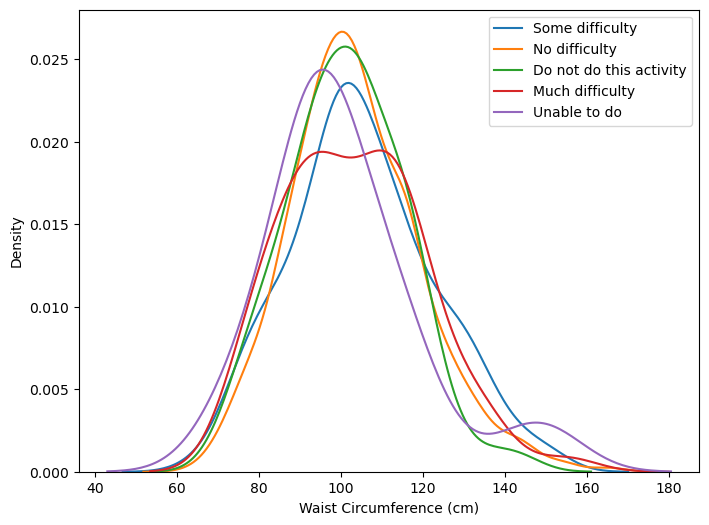

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.kdeplot(data=nhanes[nhanes['DifficultyManagingMoney'] == 'Some difficulty']['WaistCircumferenceCm'], ax=ax, label='Some difficulty')
sns.kdeplot(data=nhanes[nhanes['DifficultyManagingMoney'] == 'No difficulty']['WaistCircumferenceCm'], ax=ax, label='No difficulty')
sns.kdeplot(data=nhanes[nhanes['DifficultyManagingMoney'] == 'Do not do this activity']['WaistCircumferenceCm'], ax=ax, label='Do not do this activity')
sns.kdeplot(data=nhanes[nhanes['DifficultyManagingMoney'] == 'Much difficulty']['WaistCircumferenceCm'], ax=ax, label='Much difficulty')
sns.kdeplot(data=nhanes[nhanes['DifficultyManagingMoney'] == 'Unable to do']['WaistCircumferenceCm'], ax=ax, label='Unable to do')

ax.set_xlabel('Waist Circumference (cm)')
ax.set_ylabel('Density')
ax.legend()
plt.show()

All groups cluster around a waist circumference of 90-110 cm and tapers off below 70 cm and above 140 cm. This suggest that waist circumference is relatively normal across all groups. Some key observations include that the "No Difficulty" group has the tallest peak around 100 cm, which suggests that those individuals who do not have difficulty managing money have the least variability and concentrated around a tight average waist circumference. the "Much Difficulty" has a lower peak with a broader distribution, which suggests that individuals who have more difficulty have a wider variability in waist circumference with less strong central tendency. The "Unable to do" group has a shift central peak from 90-110 cm to 85-95 cm wiht a secondary peak from 150-160 cm. This suggests that there are a subset of individuals who have a larger wiast circumference, suggesting an association between a higher waist circumference and an inability to manage money. As difficult increases, you can see that the distributions become flatter and more spread out which can suggest that a larger waist circumference is linked with a higher difficulty in managing money but that relationship isn't perfectly linear.

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

Treat $\hat y(z)$ as a scalar parameter; differentiate and set derivative equal to zero:

$$
\frac{\partial}{\partial \hat y(z)}\mathrm{MSE}(\hat y(z))
= \frac{1}{N}\sum_{i=1}^N 2\bigl(\hat y(z)-y_i\bigr)\,\frac{1}{h}k\!\Bigl(\frac{z-x_i}{h}\Bigr)=0.
$$

Remove the constant factor $2/(N h)$ (nonzero)

$$
\sum_{i=1}^N \bigl(\hat y(z)-y_i\bigr)\,k\!\Bigl(\frac{z-x_i}{h}\Bigr)=0.
$$

Solve for $\hat y(z)$ by expanding the first term:

$$
\hat y(z)\sum_{i=1}^N k\!\Bigl(\frac{z-x_i}{h}\Bigr)
-\sum_{i=1}^N y_i\,k\!\Bigl(\frac{z-x_i}{h}\Bigr)=0.
$$

Isolate $\hat y(z)$:

$$
\hat y(z)
= \frac{\sum_{i=1}^N y_i\,k\!\bigl(\frac{z-x_i}{h}\bigr)}
{\sum_{i=1}^N k\!\bigl(\frac{z-x_i}{h}\bigr)}.
$$

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

In [45]:
import pandas as pd 
import numpy as np 

iowa = pd.read_csv('/Users/bellalu/DS 5030/DS5030UnderstandingUncertainty/data/iowa.csv')
iowa

,Invoice/Item Number,Date,Store Number,Store Name,Zip Code,Category Name,Vendor Name,Item Number,Item Description,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars)
0,INV-59108400026,06/06/2023,3723,J D SPIRITS LIQUOR,51040,STRAIGHT RYE WHISKIES,INFINIUM SPIRITS,27102,TEMPLETON RYE 4YR,750,18.09,27.14,2,54.28
1,S16879800057,01/16/2014,3926,LIQUOR DOWNTOWN / IOWA CITY,52240,VODKA 80 PROOF,HEAVEN HILL BRANDS,35416,BURNETT'S VODKA 80 PRF,750,4.84,7.26,12,87.12
2,INV-05301100019,06/05/2017,3829,GARY'S FOODS / MT VERNON,52314,CANADIAN WHISKIES,DIAGEO AMERICAS,11296,CROWN ROYAL,750,15.59,23.39,6,135.66
3,INV-40973500083,10/14/2021,5102,WILKIE LIQUORS,52314,AMERICAN SCHNAPPS,JIM BEAM BRANDS,82787,DEKUYPER BUTTERSHOTS,1000,7.87,11.81,12,141.72
4,INV-17022500013,01/18/2019,2560,HY-VEE FOOD STORE / MARION,52302,WHISKEY LIQUEUR,SAZERAC COMPANY INC,64863,FIREBALL CINNAMON WHISKEY,200,2.50,3.75,12,45.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159899,INV-20689000058,07/17/2019,2565,HY-VEE FOOD STORE #1636 / SPENCER,51301,AMERICAN CORDIALS & LIQUEURS,LUXCO INC,76488,PARAMOUNT AMARETTO,1750,8.07,12.11,6,72.66
159900,S05071400061,04/16/2012,3583,MAC'S LIQUOR AND VIDEOS,50060,COFFEE LIQUEURS,PERNOD RICARD USA/AUSTIN NICHOLS,67527,KAHLUA COFFEE LIQUEUR,1000,14.81,22.22,1,22.22
159901,INV-22880300009,10/29/2019,3896,SMOKIN' JOE'S #18 TOBACCO AND LIQUOR OUTLET,52240,IMPORTED DRY GINS,DIAGEO AMERICAS,28866,TANQUERAY GIN,750,13.50,20.25,2,40.50
159902,INV-58180900067,05/05/2023,4057,TEQUILA'S LIQUOR STORE,50316,NEUTRAL GRAIN SPIRITS FLAVORED,OLE SMOKY DISTILLERY LLC,80363,OLE SMOKY BANANA PUDDING CREAM MOONSHINE,750,13.00,19.50,3,58.50


In [46]:
print(iowa.columns)

Index(['Invoice/Item Number', 'Date', 'Store Number', 'Store Name', 'Zip Code',
       'Category Name', 'Vendor Name', 'Item Number', 'Item Description',
       'Bottle Volume (ml)', 'State Bottle Cost', 'State Bottle Retail',
       'Bottles Sold', 'Sale (Dollars)'],
      dtype='object')


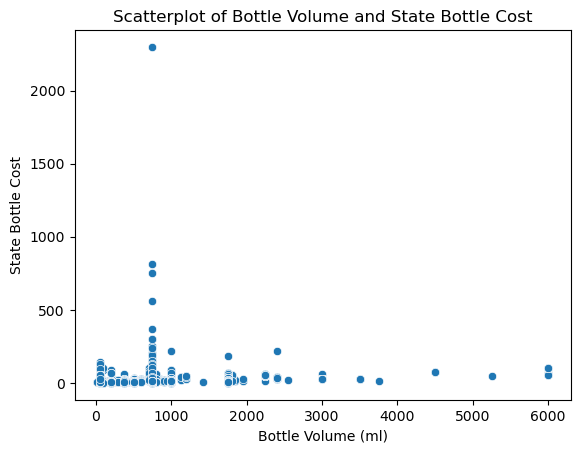

In [47]:
sns.scatterplot(data=iowa, x='Bottle Volume (ml)', y='State Bottle Cost')
plt.xlabel('Bottle Volume (ml)')
plt.ylabel('State Bottle Cost')
plt.title('Scatterplot of Bottle Volume and State Bottle Cost')
plt.show()

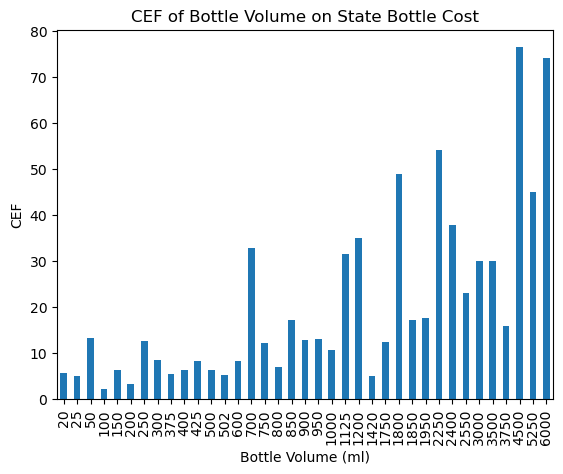

In [48]:
cef = iowa.groupby('Bottle Volume (ml)')['State Bottle Cost'].mean()
cef.plot(kind='bar')
plt.xlabel('Bottle Volume (ml)')
plt.ylabel('CEF')
plt.title('CEF of Bottle Volume on State Bottle Cost')
plt.show()

,State Bottle Cost
Bottle Volume (ml),
20,5.763750
25,5.000000
50,13.341078
100,2.120481
150,6.398333
200,3.272668
250,12.720000
300,8.437413
375,5.449283


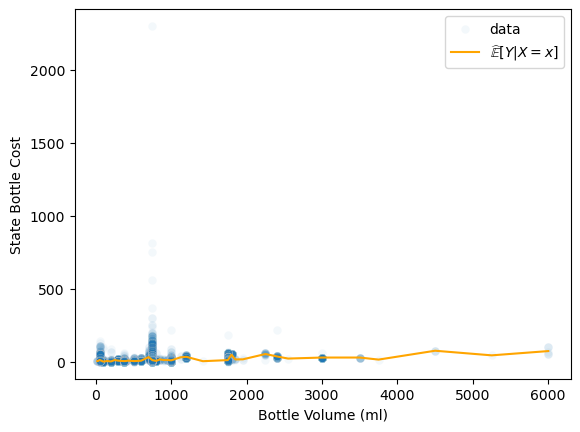

In [49]:
means = iowa.loc[:,['State Bottle Cost','Bottle Volume (ml)']].groupby('Bottle Volume (ml)').mean()
sns.scatterplot(data=iowa, y='State Bottle Cost', x='Bottle Volume (ml)',alpha=.05, label='data')
sns.lineplot(data=means, x='Bottle Volume (ml)',y='State Bottle Cost',color='orange', label='$\\widehat{\\mathbb{E}}[Y|X=x]$')

means

The relationship between Bottle Volume and State Bottle Cost might be affected by other variables such as production costs, market demand, or competition that can affect both variables. By omitting some of these variables can affect the analysis and be biased. Confounding could also occur when there are variables that affect both Bottle Volume and Bottle Cost but are associated to each variable independently. This could be production capacity or economic conditions. Regardless, there are ways to address these threats to causal identification. 

One way is to include the relevant control variables - for example if we had the data for it, we could include production costs to be introduced as a control variable to account for its affect on both variables.

